## Title
Demo funcional
### By:
Dovaribi Carupia Yagari

### Date:
2026-08-21

### Description:

Crear una demo funcional del modelo entrenado mediante un formulario online donde el usuario ingrese los datos y el modelo realice la predicción. Se utilizará Streamlit.

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/8-deploy/>.

# Entregables

Demo funcional, código de la aplicación, instrucciones para ejecutarla y enlace o captura del despliegue.

## 1. Arquitectura de inferencia

La aplicación no reentrena el modelo. Carga `models/modelo_final.joblib`, que contiene el pipeline completo seleccionado en el notebook 06. El módulo `src/model/preprocessing.py` se mantiene en el repositorio para que joblib pueda resolver `ClinicalFeatureBuilder` al cargar el artifact.

El formulario envía las columnas clínicas originales al pipeline. Las razones derivadas, imputación, transformación Yeo-Johnson, escalado y encoding se aplican internamente.

In [ ]:
import sys
from pathlib import Path

import pandas as pd
from joblib import load

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model import preprocessing as _preprocessing  # noqa: F401, E402

MODEL_PATH = PROJECT_ROOT / "models" / "modelo_final.joblib"
artifact = load(MODEL_PATH)
pipeline = artifact["pipeline"]
print(f"Modelo cargado: {artifact['model_name']}")
print(f"Ruta: {MODEL_PATH}")

## 2. Contrato de columnas y etiquetas

El formulario usa nombres amigables, pero el `DataFrame` debe conservar exactamente las columnas que espera el pipeline. Las etiquetas del proyecto quedan así:

| Código interno | Texto mostrado |
| --- | --- |
| `1` | Enfermedad hepática |
| `0` | Sin enfermedad hepática |

El CSV original usaba `Dataset=1` para enfermo y `Dataset=2` para no enfermo; el notebook 04 renombró esa columna a `Diagnosis` y el notebook 06 transformó `2` a `0`.

In [ ]:
sample_input = pd.DataFrame(
    [
        {
            "Age": 45,
            "Gender": "Male",
            "Total_Bilirubin": 1.0,
            "Direct_Bilirubin": 0.3,
            "Alkaline_Phosphotase": 210.0,
            "Alamine_Aminotransferase": 36.0,
            "Aspartate_Aminotransferase": 42.0,
            "Total_Protiens": 6.5,
            "Albumin": 3.1,
            "Albumin_and_Globulin_Ratio": 0.9,
        }
    ]
)
prediction = int(pipeline.predict(sample_input)[0])
probabilities = pipeline.predict_proba(sample_input)[0]
disease_probability = float(probabilities[list(pipeline.classes_).index(1)])

label = {
    1: "Enfermedad hepática",
    0: "Sin enfermedad hepática",
}[prediction]
print(f"Predicción: {label}")
print(f"Probabilidad de enfermedad: {disease_probability:.2%}")

## 3. Ejecución local y despliegue

Desde la raíz del repositorio:

```bash
uv run streamlit run app.py
```

Para desplegar en Streamlit Community Cloud:

1. Confirmar que `app.py`, `models/modelo_final.joblib`, `src/model/preprocessing.py` y `requirements.txt` estén en la rama publicada.
2. Ejecutar `uvx pre-commit run --all-files`.
3. Crear el commit y hacer push.
4. Entrar a Streamlit Community Cloud y seleccionar **New app**.
5. Seleccionar el repositorio, la rama y `app.py` como archivo principal.
6. Pulsar **Deploy** y revisar los logs.
7. Probar valores normales, valores límite y entradas inválidas.

La aplicación no requiere secrets porque el modelo se distribuye como artifact local del repositorio.

## 4. Limitaciones

La demo es académica. La probabilidad no es un diagnóstico y el modelo fue entrenado con un dataset pequeño y específico. Antes de un uso clínico serían necesarias validación externa, calibración, revisión médica, monitoreo de drift y controles de privacidad.

# Imagen demo funcional

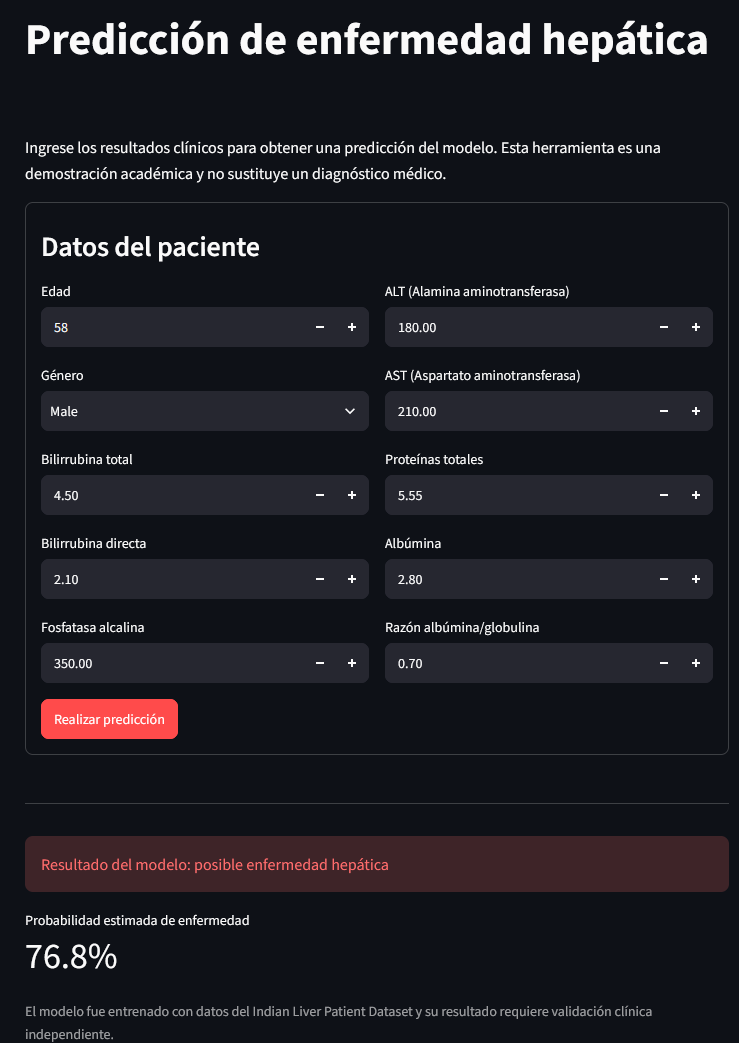